# Plan

**Baseline regression workflow**

1. Inputs: binary genotype vector from surrogate_preprocessed_seed_default_generation_long.csv and surrogate_preprocessed_ko441_generation_long.csv.
2. Target: one-generation growth rate in /h, derived from the raw parquet timeseries.
3. Preprocess labels: estimate growth only from the earliest stable interval; if a lineage shows a rise before death, truncate at the first local peak and keep only the pre-peak slope. Treat later generations after death as censored/missing, not as training targets.
4. Aggregate replicates with median growth per genotype-generation.
5. Baseline model: start with polynomial regression; then compare with XGBoost or LightGBM.
6. Evaluation: split by genotype, report MAE/RMSE in /h, and use recursive prediction for generation-by-generation simulation.

**Linear, Ridge, and ElasticNet Model**
- All Model Assumptions

All models assume that growth rate can be approximated as a linear combination of TU availability features:

$$
\hat{y} = \beta_0 + \sum_{i=1}^{p} \beta_i x_i
$$

where ($x_i \in {0,1}$) indicates whether transcription unit (i) is available.

- Linear Regression (Ordinary Least Squares)

OLS estimates coefficients by minimizing the residual sum of squares:

$$
\min_{\beta} |y - X\beta|_2^2
$$

This assumes that TU effects are additive and approximately linear.

- Ridge Regression

Ridge adds an L2 penalty to shrink coefficient magnitudes:

$$
\min_{\beta} |y - X\beta|_2^2 + \lambda |\beta|_2^2
$$

This assumes that most TUs contribute to growth and improves stability when features are highly correlated.

- Elastic Net Regression

Elastic Net combines L1 and L2 regularization:

$$
\min_{\beta} |y - X\beta|_2^2

\lambda \left(
\alpha |\beta|_1
\frac{1-\alpha}{2}|\beta|_2^2
\right)
$$

This assumes that only a subset of TUs may have strong effects while retaining robustness to correlated features.

# Workflow flowchart

# Baseline Linear Model - default KO data

## Data loading and inspection

Training dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.parquet

csv formated dataset: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv

Training features: /user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv

In [ ]:
feature_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv"
genotype_feature = pd.read_csv(feature_path)
print(f"Genotype feature count: {len(genotype_feature)}")
print(genotype_feature.head(20).to_string(index=False))

training_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_level_training_dataset_growth_filtered2.csv"
training_df = pd.read_csv(training_path)
print(f"Training dataset rows: {len(training_df)}")
print(f"KO rows in training dataset: {int(training_df['run_type'].eq('KO').sum())}")
print(f"Baseline rows in training dataset: {int(training_df['run_type'].eq('baseline').sum())}")
print(training_df.head(20).to_string(index=False))

Genotype feature count: 350
                feature_name
tu_available__EG10016_RNA[c]
tu_available__EG10214_RNA[c]
tu_available__EG10383_RNA[c]
tu_available__EG10901_RNA[c]
tu_available__EG10982_RNA[c]
tu_available__EG12662_RNA[c]
tu_available__EG12663_RNA[c]
      tu_available__TU0-0[c]
   tu_available__TU0-1002[c]
   tu_available__TU0-1021[c]
   tu_available__TU0-1063[c]
  tu_available__TU0-12797[c]
  tu_available__TU0-12810[c]
  tu_available__TU0-12812[c]
  tu_available__TU0-12827[c]
  tu_available__TU0-12831[c]
  tu_available__TU0-12833[c]
  tu_available__TU0-12838[c]
  tu_available__TU0-12921[c]
  tu_available__TU0-12924[c]
Training dataset rows: 724
KO rows in training dataset: 722
Baseline rows in training dataset: 2
                                                    sample_id                                                              source_file  lineage_seed                             project  variant              label run_type       ko_tu_id  mean_growth_rate  median_gro

## Train SVM model

**Research Objective & Method Summary**

- Objective

The goal is to quantify and interpret the effect of single operon knockouts on cellular growth using WholeCell-style simulation data. The focus is not on general-purpose prediction, but on estimating operon-specific effects, ranking operon importance, and assessing robustness across stochastic simulation seeds. Formally, we aim to approximate $$\mathbb{E}[\text{growth} \mid \text{operon knockout}]$$.

- Data structure

The dataset contains ~350 operons (TUs), each simulated under 2 stochastic seeds, giving ~700 samples in total. Each sample corresponds to a single operon knockout. Genotypes are encoded as binary presence/absence vectors where wild-type is all ones ($x_i = 1$ for all $i$), and a knockout of operon $k$ sets $x_k = 0$ while all others remain 1.

- Model formulation

We use a linear model of the form $$\text{growth} = \beta_0 + \sum_{i=1}^{350} \beta_i x_i$$.

For a single knockout of operon $k$, this becomes $$\text{growth}_{KO_k} = C - \beta_k$$, where $C$ is a constant baseline term. Each coefficient $\beta_i$ represents the growth effect (penalty or benefit) of removing operon $i$.

- Key property

Each genotype appears only twice (two seeds), and the design matrix is highly structured with strong collinearity. The model is effectively estimating one parameter per operon, rather than learning complex feature interactions. As a result, standard random train/test splits are not meaningful.

- Evaluation strategy

Random row splits leak operon identity across train and test, while operon-level splits remove all information for unseen knockouts and are not informative. The most meaningful validation is to train on one seed and test on the other, i.e., train on seed 1 and evaluate on seed 2 (or vice versa), to assess reproducibility of estimated effects across stochastic simulations.

- Approach

For scientific interpretation, use all ~700 samples to fit the model and estimate coefficients. Report $\beta_i$ values, their ranking, and variability across seeds. Given the low sample-to-parameter ratio and collinearity, ridge regression is recommended:
$$\min_{\beta} \|y - X\beta\|^2 + \lambda \|\beta\|^2$$
This stabilizes coefficient estimates under noise from stochastic simulation.

- Interpretation

The model should be viewed as a linear decomposition of operon knockout effects on growth rather than a predictive machine learning system. The main output is a ranked list of operons by inferred growth impact and an assessment of robustness across simulation replicates.

**To-Do**

1. Resplit the training and testing dataset to better fit the research purpose - done

2. Test SVM, NN, and HDC models for the same training sets.

### Customised training/testing split

In [ ]:
"""1) Full dataset (train=test)
2) Train on seed A, test on seed B
3) Train on seed B, test on seed A"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

Using 350 features | X: (724, 350) | y: (724,)


In [ ]:
"""Train three linear regression models:
1) Full dataset (train=test)
2) Train on seed A, test on seed B
3) Train on seed B, test on seed A"""

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

# -----------------------------
# Helper function
# -----------------------------
def train_eval(X_train, y_train, X_test, y_test, label):
    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n[{label}]")
    print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

    return model, rmse, r2

# -----------------------------
# 1. Full dataset (train=test)
# -----------------------------
model_full, rmse_full, r2_full = train_eval(X, y, X, y, "Full dataset (train=test)")

# -----------------------------
# 2. Train seed A → Test seed B
# -----------------------------
model_A, rmse_A_B, r2_A_B = train_eval(X_A, y_A, X_B, y_B, "Train A → Test B")

# -----------------------------
# 3. Train seed B → Test seed A
# -----------------------------
model_B, rmse_B_A, r2_B_A = train_eval(X_B, y_B, X_A, y_A, "Train B → Test A")

# -----------------------------
# Coefficients (from full model)
# -----------------------------
coef = pd.Series(model_full.coef_, index=tu_cols)

print("\nTop 10 TU coefficients from full model:")
print(coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save models
# -----------------------------
joblib.dump(model_full, SURROGATE_DIR + "/linear_full.pkl")
joblib.dump(model_A, SURROGATE_DIR + "/linear_seedA.pkl")
joblib.dump(model_B, SURROGATE_DIR + "/linear_seedB.pkl")

print("\nModels saved.")

Using 350 features | X: (724, 350) | y: (724,)

[Full dataset (train=test)]
RMSE: 0.028940 | R2: 0.9930

[Train A → Test B]
RMSE: 0.057855 | R2: 0.9714

[Train B → Test A]
RMSE: 0.057855 | R2: 0.9717

Top 10 TU coefficients from full model:
tu_available__TU0-13135[c]    0.863388
tu_available__TU0-13593[c]    0.863388
tu_available__TU0-1021[c]     0.863388
tu_available__TU0-14004[c]    0.863388
tu_available__TU0-13444[c]    0.863388
tu_available__TU0-14042[c]    0.863388
tu_available__TU0-6660[c]     0.863388
tu_available__TU0-7842[c]     0.863388
tu_available__TU00336[c]      0.863388
tu_available__TU00178[c]      0.863388
dtype: float64

Models saved.


In [ ]:
import numpy as np

# check column variance
col_std = X.std(axis=0)

print("Num zero-variance features:", np.sum(col_std == 0))
print("Min std:", np.min(col_std))
print("Max std:", np.max(col_std))

Num zero-variance features: 0
Min std: 0.052486187845303865
Max std: 0.07412380035910907


In [ ]:
# check if columns are accidentally identical
unique_cols = np.unique(X, axis=1).shape[1]
print("Original features:", X.shape[1])
print("Unique features:", unique_cols)

Original features: 350
Unique features: 350


In [ ]:
# -----------------------------
# Aggregate coefficients
# -----------------------------

coef_df = pd.DataFrame({
    "tu": tu_cols,
    "coef_full": model_full.coef_,
    "coef_seedA_train": model_A.coef_,
    "coef_seedB_train": model_B.coef_
})

# Optional: add absolute values for ranking
coef_df["abs_full"] = np.abs(coef_df["coef_full"])
coef_df["abs_seedA_train"] = np.abs(coef_df["coef_seedA_train"])
coef_df["abs_seedB_train"] = np.abs(coef_df["coef_seedB_train"])

# Optional: stability metrics across models
coef_df["coef_mean"] = coef_df[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].mean(axis=1)

coef_df["coef_std"] = coef_df[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].std(axis=1)

# Rank by stability-weighted importance (optional but useful)
coef_df["stability_score"] = coef_df["abs_mean"] = np.abs(coef_df["coef_mean"])

# Sort by strongest average effect
coef_df = coef_df.sort_values(by="stability_score", ascending=False)

# -----------------------------
# Save
# -----------------------------
out_path = SURROGATE_DIR + "/TU_coefficients_3_linear_models.csv"
coef_df.to_csv(out_path, index=False)

print(f"Saved aggregated coefficients to: {out_path}")

Saved aggregated coefficients to: /user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv


In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Output directory
# -----------------------------
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

gene_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[gene_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"X: {X.shape}, y: {y.shape}")

# -----------------------------
# Seed split (A / B)
# -----------------------------
df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

print(f"Seed A: {X_A.shape}, Seed B: {X_B.shape}")

# -----------------------------
# Hyperparameters
# -----------------------------
alphas_ridge = np.logspace(-4, 4, 25)

# -----------------------------
# Model factories
# -----------------------------
def make_ridge():
    return make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas_ridge, cv=5, scoring="neg_mean_squared_error")
    )

def make_enet():
    return make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            alphas=np.logspace(-4, 1, 30),
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
            max_iter=5000
        )
    )

# -----------------------------
# Evaluation helper
# -----------------------------
def eval_model(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n[{label}]")
    print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

    return model, rmse, r2

# -----------------------------
# 1. Full dataset (train=test)
# -----------------------------
ridge_full, ridge_full_rmse, ridge_full_r2 = eval_model(
    make_ridge(), X, y, X, y, "Ridge FULL (train=test)"
)

enet_full, enet_full_rmse, enet_full_r2 = eval_model(
    make_enet(), X, y, X, y, "ElasticNet FULL (train=test)"
)

# -----------------------------
# 2. Train A → Test B
# -----------------------------
ridge_A, ridge_A_rmse, ridge_A_r2 = eval_model(
    make_ridge(), X_A, y_A, X_B, y_B, "Ridge A → B"
)

enet_A, enet_A_rmse, enet_A_r2 = eval_model(
    make_enet(), X_A, y_A, X_B, y_B, "ElasticNet A → B"
)

# -----------------------------
# 3. Train B → Test A
# -----------------------------
ridge_B, ridge_B_rmse, ridge_B_r2 = eval_model(
    make_ridge(), X_B, y_B, X_A, y_A, "Ridge B → A"
)

enet_B, enet_B_rmse, enet_B_r2 = eval_model(
    make_enet(), X_B, y_B, X_A, y_A, "ElasticNet B → A"
)

# -----------------------------
# Coefficient extraction
# -----------------------------
def get_coefs(pipe):
    scaler = pipe.named_steps["standardscaler"]
    model = pipe.named_steps[list(pipe.named_steps.keys())[-1]]
    return pd.Series(model.coef_ / scaler.scale_, index=gene_cols)

# Full model coefficients (primary)
ridge_coef = get_coefs(ridge_full)
enet_coef = get_coefs(enet_full)

# -----------------------------
# Top coefficients
# -----------------------------
print("\nTop Ridge coefficients (full):")
print(ridge_coef.abs().sort_values(ascending=False).head(10))

print("\nTop ElasticNet coefficients (full):")
print(enet_coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save models
# -----------------------------
joblib.dump(ridge_full, SURROGATE_DIR + "/ridge_full.pkl")
joblib.dump(ridge_A, SURROGATE_DIR + "/ridge_A.pkl")
joblib.dump(ridge_B, SURROGATE_DIR + "/ridge_B.pkl")

joblib.dump(enet_full, SURROGATE_DIR + "/enet_full.pkl")
joblib.dump(enet_A, SURROGATE_DIR + "/enet_A.pkl")
joblib.dump(enet_B, SURROGATE_DIR + "/enet_B.pkl")

print("\nAll models saved.")

X: (724, 350), y: (724,)
Seed A: (340, 350), Seed B: (340, 350)

[Ridge FULL (train=test)]
RMSE: 0.030303 | R2: 0.9924

[ElasticNet FULL (train=test)]
RMSE: 0.036320 | R2: 0.9891

[Ridge A → B]
RMSE: 0.057780 | R2: 0.9715

[ElasticNet A → B]
RMSE: 0.342043 | R2: -0.0001

[Ridge B → A]
RMSE: 0.059117 | R2: 0.9704

[ElasticNet B → A]
RMSE: 0.343901 | R2: -0.0001

Top Ridge coefficients (full):
tu_available__TU00067[c]      0.693385
tu_available__TU0-1[c]        0.693385
tu_available__TU0-6512[c]     0.693385
tu_available__TU00205[c]      0.693385
tu_available__TU00348[c]      0.693373
tu_available__TU0-42202[c]    0.693373
tu_available__TU00352[c]      0.693373
tu_available__TU0-7842[c]     0.693373
tu_available__TU0-6660[c]     0.693373
tu_available__TU00340[c]      0.693373
dtype: float64

Top ElasticNet coefficients (full):
tu_available__TU00205[c]     0.776564
tu_available__TU00067[c]     0.776562
tu_available__TU0-6512[c]    0.776559
tu_available__TU0-1[c]       0.776555
tu_availabl

In [ ]:
# -----------------------------
# Aggregate coefficients
# -----------------------------

coef_df = pd.DataFrame({
    "tu": gene_cols,

    # Ridge models
    "ridge_full": get_coefs(ridge_full),
    "ridge_A_train": get_coefs(ridge_A),
    "ridge_B_train": get_coefs(ridge_B),

    # ElasticNet models
    "enet_full": get_coefs(enet_full),
    "enet_A_train": get_coefs(enet_A),
    "enet_B_train": get_coefs(enet_B),
})

# -----------------------------
# Optional: absolute values for ranking
# -----------------------------
for c in [
    "ridge_full", "ridge_A_train", "ridge_B_train",
    "enet_full", "enet_A_train", "enet_B_train"
]:
    coef_df[f"abs_{c}"] = np.abs(coef_df[c])

# -----------------------------
# Stability metrics across models
# (Ridge)
# -----------------------------
coef_df["ridge_mean"] = coef_df[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train"
]].mean(axis=1)

coef_df["ridge_std"] = coef_df[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train"
]].std(axis=1)

# (ElasticNet)
coef_df["enet_mean"] = coef_df[[
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].mean(axis=1)

coef_df["enet_std"] = coef_df[[
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].std(axis=1)

# -----------------------------
# Rank by stability-weighted importance
# -----------------------------
coef_df["ridge_score"] = np.abs(coef_df["ridge_mean"])
coef_df["enet_score"] = np.abs(coef_df["enet_mean"])

# Default ranking (you can switch later)
coef_df = coef_df.sort_values(by="ridge_score", ascending=False)

# -----------------------------
# Save
# -----------------------------
out_path = SURROGATE_DIR + "/TU_coefficients_6_Regularized_models.csv"
coef_df.to_csv(out_path, index=False)

print(f"Saved aggregated coefficients to: {out_path}")

Saved aggregated coefficients to: /user/home/il22158/work/vEcoli/surrogate/TU_coefficients_6_Regularized_models.csv


### Coeficient plots of saved 9 model coes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

linear_path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
reg_path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_6_Regularized_models.csv"

df_lin = pd.read_csv(linear_path)
df_reg = pd.read_csv(reg_path)

In [ ]:
df_lin["coef_mean"] = df_lin[[
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]].mean(axis=1)

df_reg["reg_mean"] = df_reg[[
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train",
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]].mean(axis=1)

In [ ]:
df = pd.merge(
    df_lin,
    df_reg,
    on="tu",
    suffixes=("_lin", "_reg")
)

OLS = Ordinary Least Squares

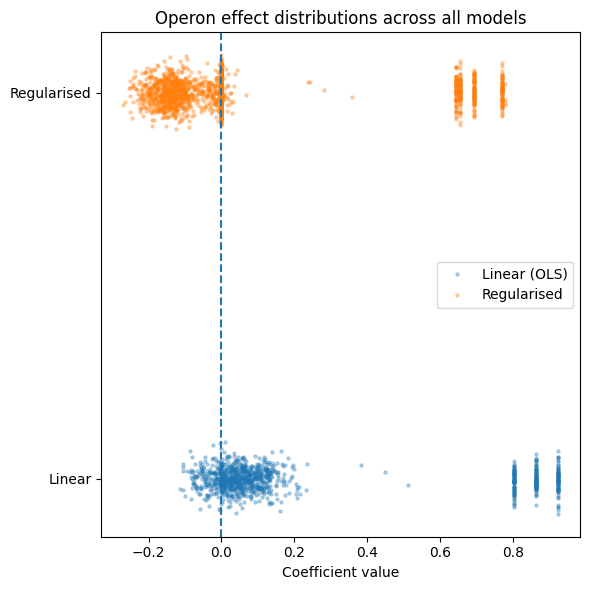

In [ ]:
"""figure1: Linear vs Regularized consensus"""

lin_cols = [
    "coef_full",
    "coef_seedA_train",
    "coef_seedB_train"
]

reg_cols = [
    "ridge_full",
    "ridge_A_train",
    "ridge_B_train",
    "enet_full",
    "enet_A_train",
    "enet_B_train"
]

# -----------------------------
# Stack into long format (no merging needed)
# -----------------------------
lin_vals = df_lin[lin_cols].values.flatten()
reg_vals = df_reg[reg_cols].values.flatten()

# Remove NaNs just in case
lin_vals = lin_vals[~np.isnan(lin_vals)]
reg_vals = reg_vals[~np.isnan(reg_vals)]

# -----------------------------
# Plot (2-group comparison)
# -----------------------------
plt.figure(figsize=(6,6))

y_lin = np.random.normal(0, 0.03, len(lin_vals))
y_reg = np.random.normal(1, 0.03, len(reg_vals))

plt.scatter(lin_vals, y_lin, s=5, alpha=0.3, color="tab:blue", label="Linear (OLS)")
plt.scatter(reg_vals, y_reg, s=5, alpha=0.3, color="tab:orange", label="Regularised")

plt.axvline(0, linestyle="--")

plt.yticks([0, 1], ["Linear", "Regularised"])
plt.xlabel("Coefficient value")
plt.title("Operon effect distributions across all models")

plt.legend()
plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/operon_effects_comparison_lin_vs_reg.png")
plt.show()

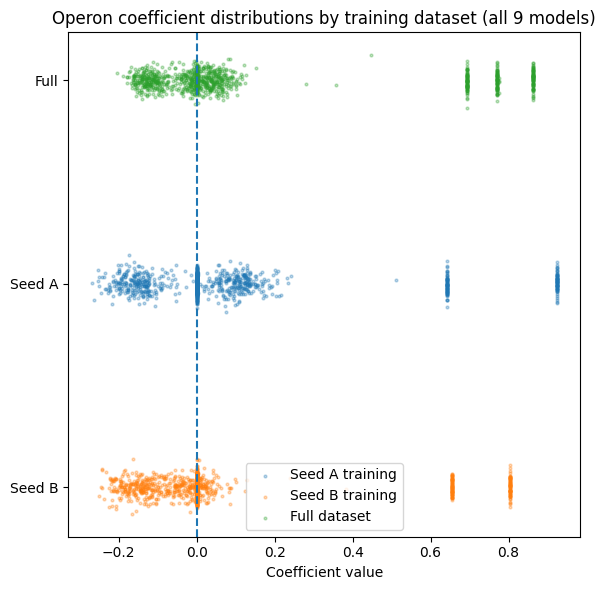

In [ ]:
"""figure1.2: Comparison of training origins (seed A vs seed B vs full) across all models"""
# -----------------------------
# Build (coef, group) pairs
# group = training origin
# -----------------------------

data_A = []
data_B = []
data_full = []

# Linear models
data_full += list(df_lin["coef_full"].dropna().values)
data_A    += list(df_lin["coef_seedA_train"].dropna().values)
data_B    += list(df_lin["coef_seedB_train"].dropna().values)

# Regularised models
data_full += list(df_reg["ridge_full"].dropna().values)
data_full += list(df_reg["enet_full"].dropna().values)

data_A += list(df_reg["ridge_A_train"].dropna().values)
data_A += list(df_reg["enet_A_train"].dropna().values)

data_B += list(df_reg["ridge_B_train"].dropna().values)
data_B += list(df_reg["enet_B_train"].dropna().values)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))

y_full = np.random.normal(2, 0.04, len(data_full))
y_A    = np.random.normal(1, 0.04, len(data_A))
y_B    = np.random.normal(0, 0.04, len(data_B))

plt.scatter(data_A, y_A, s=4, alpha=0.3, color="tab:blue", label="Seed A training")
plt.scatter(data_B, y_B, s=4, alpha=0.3, color="tab:orange", label="Seed B training")
plt.scatter(data_full, y_full, s=4, alpha=0.3, color="tab:green", label="Full dataset")

plt.axvline(0, linestyle="--")

plt.yticks([0,1,2], ["Seed B", "Seed A", "Full"])
plt.xlabel("Coefficient value")
plt.title("Operon coefficient distributions by training dataset (all 9 models)")

plt.legend()
plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/operon_effects_comparison_by_training_data.png")
plt.show()

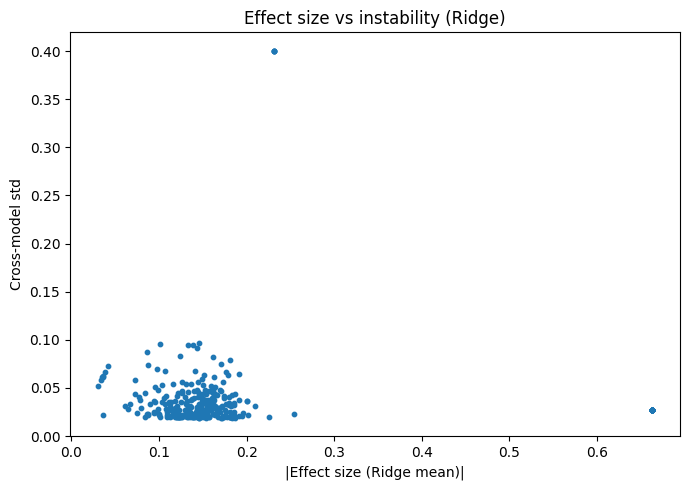

In [ ]:
"""figure2:Stability vs effect size"""

plt.figure(figsize=(7,5))

plt.scatter(
    np.abs(df["ridge_mean"]),
    df["ridge_std"],
    s=10
)

plt.xlabel("|Effect size (Ridge mean)|")
plt.ylabel("Cross-model std")
plt.title("Effect size vs instability (Ridge)")

plt.tight_layout()
plt.show()

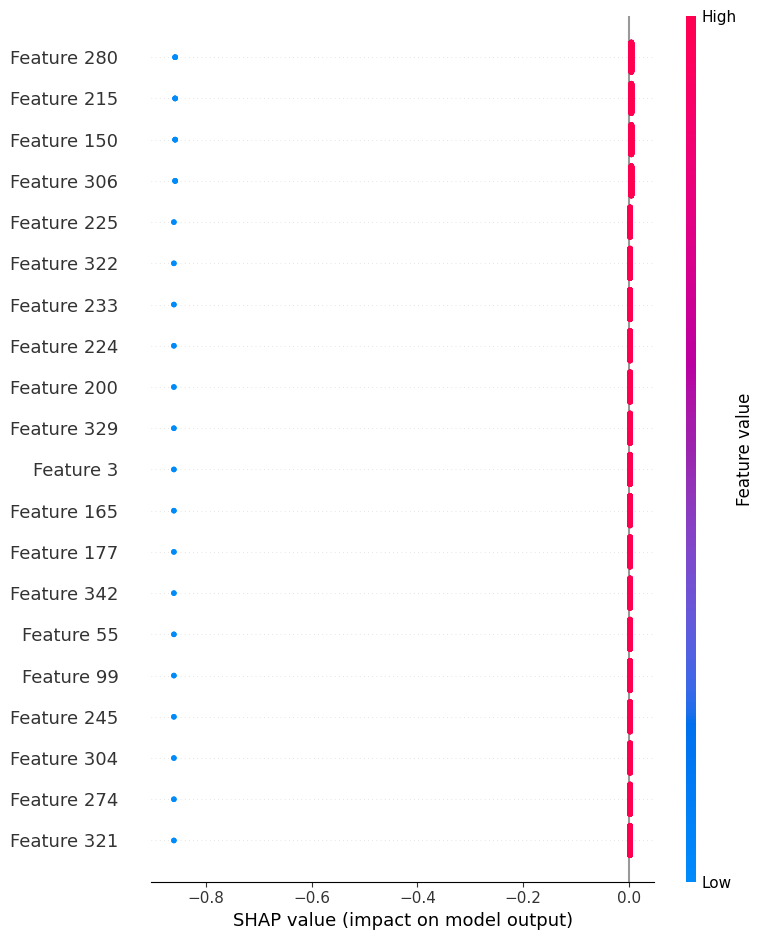

In [ ]:
"""figure3: Top operon ranking (most accurate model)"""
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# =========================
# 1. Load feature list
# =========================
feature_list_path = "/user/home/il22158/work/vEcoli/surrogate/train_data/TU_feature_list.csv"
feature_df = pd.read_csv(feature_list_path)

features = feature_df["feature_name"].tolist()

# =========================
# 2. Load model
# =========================
model_path = "/user/home/il22158/work/vEcoli/surrogate/linear_full.pkl"
model = joblib.load(model_path)

# =========================
# 3. Reconstruct X correctly
# IMPORTANT: you must load your REAL dataset here
# =========================
# X is loaded in previous step

# =========================
# 4. SHAP (modern API, no warnings)
# =========================
masker = shap.maskers.Independent(
    X,
    max_samples=X.shape[0]   # = 350
)

explainer = shap.LinearExplainer(
    model,
    masker
)

shap_values = explainer(X)

# =========================
# 5. Plot (beeswarm, not bar plot)
# =========================
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X, show=True)

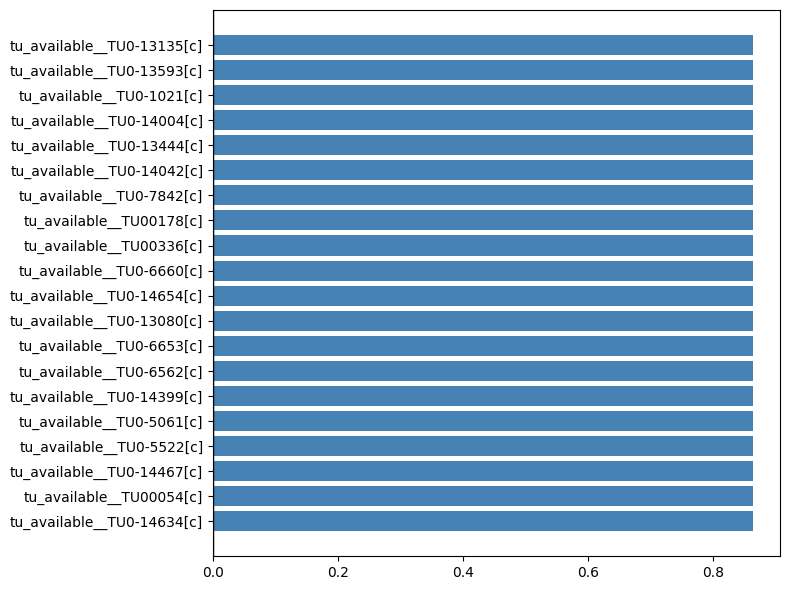

In [ ]:
"""figure 3.2 a simple bar plot of top coefficients from the best model (for direct comparison with SHAP)"""
# =========================
# load coefficients
# =========================
path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
df = pd.read_csv(path)

# ensure numeric
df["coef_full"] = pd.to_numeric(df["coef_full"], errors="coerce")
df = df.dropna(subset=["coef_full"])

# =========================
# select top coefficients
# =========================
top_n = 20

df_top = df.copy()
df_top["abs_coef"] = df_top["coef_full"].abs()

df_top = df_top.sort_values("abs_coef", ascending=False).head(top_n)

# sort for plotting (nice visual order)
df_top = df_top.sort_values("coef_full")

# =========================
# plot
# =========================
plt.figure(figsize=(8, 6))

colors = df_top["coef_full"].apply(lambda x: "red" if x < 0 else "steelblue")

plt.barh(df_top["tu"], df_top["coef_full"], color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


Cluster sizes:
group
0    118
1     80
2    151
3      1
Name: count, dtype: int64


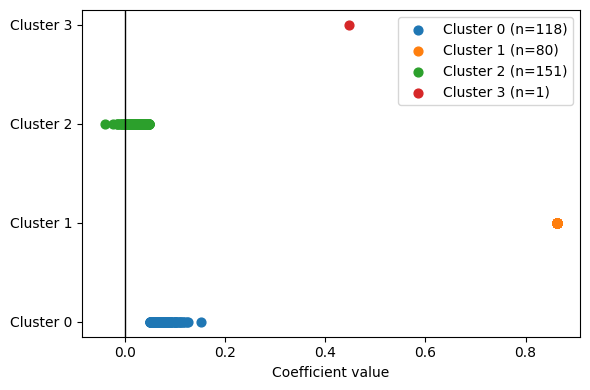

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# =========================
# load data
# =========================
path = "/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_3_linear_models.csv"
df = pd.read_csv(path)

df["coef_full"] = pd.to_numeric(df["coef_full"], errors="coerce")
df = df.dropna(subset=["coef_full"])

# =========================
# clustering
# =========================
X = df[["coef_full"]].values

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
df["group"] = kmeans.fit_predict(X)

# =========================
# cluster sizes
# =========================
cluster_counts = df["group"].value_counts().sort_index()

print("\nCluster sizes:")
print(cluster_counts)

# =========================
# plot
# =========================
plt.figure(figsize=(6, 4))

for g in sorted(df["group"].unique()):
    subset = df[df["group"] == g]

    plt.scatter(
        subset["coef_full"],
        np.full(len(subset), g),
        s=40,
        label=f"Cluster {g} (n={len(subset)})"
    )

plt.axvline(0, color="black", linewidth=1)

plt.yticks(range(n_clusters), [f"Cluster {i}" for i in range(n_clusters)])
plt.xlabel("Coefficient value")

plt.legend()
plt.tight_layout()
plt.savefig("/user/home/il22158/work/vEcoli/surrogate/TU_coefficients_linear_full_clustered.png")
plt.show()

### Accuracy plots

In [ ]:
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Seed ordering (IMPORTANT)
# -----------------------------
# We assume each TU appears twice (two seeds) in a consistent order in df
# We construct a simple alternating index split:
# first occurrence -> seed A
# second occurrence -> seed B

df = df.reset_index(drop=True)

seed_mask_A = np.zeros(len(df), dtype=bool)
seed_mask_B = np.zeros(len(df), dtype=bool)

# group by TU and assign first/second occurrence
for _, idx in df.groupby("ko_tu_id").groups.items():
    idx = list(idx)
    if len(idx) != 2:
        continue  # safety check for unexpected duplicates
    seed_mask_A[idx[0]] = True
    seed_mask_B[idx[1]] = True

X_A, y_A = X[seed_mask_A], y[seed_mask_A]
X_B, y_B = X[seed_mask_B], y[seed_mask_B]

Using 350 features | X: (724, 350) | y: (724,)


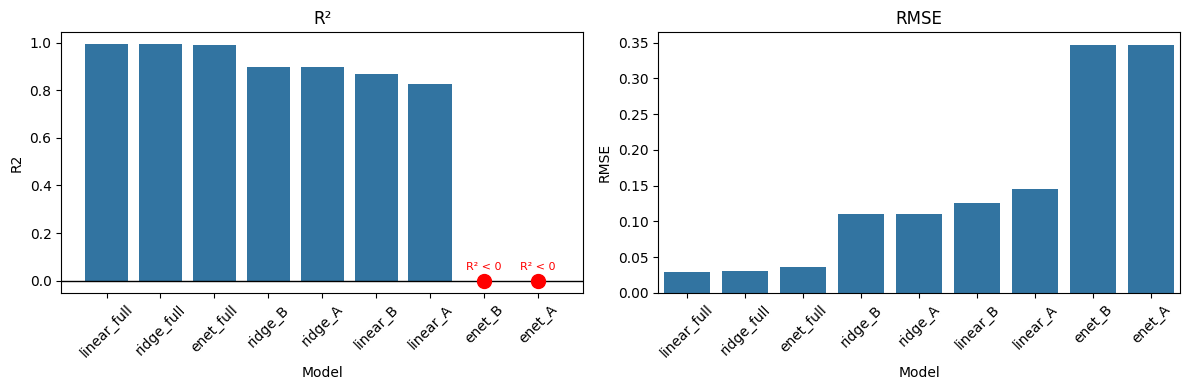

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error

model_paths = {
    "enet_A": "/user/home/il22158/work/vEcoli/surrogate/enet_A.pkl",
    "enet_B": "/user/home/il22158/work/vEcoli/surrogate/enet_B.pkl",
    "enet_full": "/user/home/il22158/work/vEcoli/surrogate/enet_full.pkl",
    "linear_A": "/user/home/il22158/work/vEcoli/surrogate/linear_seedA.pkl",
    "linear_B": "/user/home/il22158/work/vEcoli/surrogate/linear_seedB.pkl",
    "linear_full": "/user/home/il22158/work/vEcoli/surrogate/linear_full.pkl",
    "ridge_A": "/user/home/il22158/work/vEcoli/surrogate/ridge_A.pkl",
    "ridge_B": "/user/home/il22158/work/vEcoli/surrogate/ridge_B.pkl",
    "ridge_full": "/user/home/il22158/work/vEcoli/surrogate/ridge_full.pkl",
}

results = []

for name, path in model_paths.items():
    model = joblib.load(path)
    y_pred = model.predict(X)

    results.append({
        "Model": name,
        "R2": r2_score(y, y_pred),
        "RMSE": root_mean_squared_error(y, y_pred)
    })

df = pd.DataFrame(results).sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================
# R2 BARPLOT
# =========================
sns.barplot(data=df, x="Model", y="R2", ax=axes[0], errorbar=None)

axes[0].set_title("R²")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="black", linewidth=1)

# 🔥 map model name → x position
x_positions = {label.get_text(): i for i, label in enumerate(axes[0].get_xticklabels())}

# 🔴 correct placement of negative markers
for _, row in df.iterrows():
    if row["R2"] < 0:
        x = x_positions[row["Model"]]

        axes[0].scatter(
            x,
            row["R2"],
            color="red",
            s=100,
            zorder=5
        )

        axes[0].annotate(
            "R² < 0",
            (x, row["R2"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            color="red",
            fontsize=8
        )

# =========================
# RMSE PLOT
# =========================
sns.barplot(data=df, x="Model", y="RMSE", ax=axes[1], errorbar=None)
axes[1].set_title("RMSE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(SURROGATE_DIR + "/9_base_model_performance_comparison.png")
plt.show()

In [ ]:
print("\nModel performance:")
print(df.sort_values("R2", ascending=False).to_string(index=False))


Model performance:
      Model        R2     RMSE
linear_full  0.993050 0.028940
 ridge_full  0.992379 0.030303
  enet_full  0.989053 0.036320
    ridge_B  0.898488 0.110599
    ridge_A  0.898438 0.110627
   linear_B  0.868135 0.126054
   linear_A  0.825676 0.144935
     enet_B -0.000291 0.347181
     enet_A -0.000634 0.347241


### 5 CV training and testing

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"])

tu_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[tu_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"Using {len(tu_cols)} features | X: {X.shape} | y: {y.shape}")

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Holdout evaluation
# -----------------------------
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.6f} | R2: {r2:.4f}")

# -----------------------------
# 5-fold CV (RMSE)
# -----------------------------
cv_rmse = np.sqrt(
    -cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
)

print(f"CV RMSE: {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}")

# -----------------------------
# Top coefficients
# -----------------------------
coef = pd.Series(model.coef_, index=tu_cols)

print("\nTop 10 TU coefficients:")
print(coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# Save model
# -----------------------------
joblib.dump(model, SURROGATE_DIR + "/" + "baseline_linear_TU_model.pkl")
print("Model saved.")

Using 350 features | X: (796, 350) | y: (796,)
RMSE: 0.217293 | R2: 0.6802
CV RMSE: 0.181913 ± 0.246839

Top 10 TU coefficients:
tu_available__TU0-8492[c]     0.845027
tu_available__TU0-6512[c]     0.845027
tu_available__TU0-14399[c]    0.845027
tu_available__TU00351[c]      0.845027
tu_available__TU0-1[c]        0.845027
tu_available__TU00205[c]      0.845027
tu_available__TU0-13444[c]    0.845027
tu_available__TU00061[c]      0.845027
tu_available__TU0-6660[c]     0.845027
tu_available__TU0-14042[c]    0.845027
dtype: float64
Model saved.


In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Out directory
SURROGATE_DIR = "/user/home/il22158/work/vEcoli/surrogate"

# -----------------------------
# Data
# -----------------------------
df = training_df.dropna(subset=["growth_next_h"]).copy()

gene_cols = [c for c in df.columns if c.startswith("tu_available__")]

X = df[gene_cols].astype(np.int8).values
y = df["growth_next_h"].astype(float).values

print(f"X: {X.shape}, y: {y.shape}")

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas_ridge = np.logspace(-4, 4, 25)

# -----------------------------
# Ridge
# -----------------------------
ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas_ridge, cv=5, scoring="neg_mean_squared_error")
)

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Ridge -> RMSE: {ridge_rmse:.6f} | R2: {ridge_r2:.4f}")

ridge_cv = np.sqrt(
    -cross_val_score(ridge, X, y, cv=5, scoring="neg_mean_squared_error")
)
print(f"Ridge CV RMSE: {ridge_cv.mean():.6f} ± {ridge_cv.std():.6f}")

# -----------------------------
# ElasticNet
# -----------------------------
enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        alphas=np.logspace(-4, 1, 30),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=5000
    )
)

enet.fit(X_train, y_train)
enet_pred = enet.predict(X_test)

enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)

print(f"ElasticNet -> RMSE: {enet_rmse:.6f} | R2: {enet_r2:.4f}")

enet_cv = np.sqrt(
    -cross_val_score(enet, X, y, cv=5, scoring="neg_mean_squared_error")
)
print(f"ElasticNet CV RMSE: {enet_cv.mean():.6f} ± {enet_cv.std():.6f}")

# -----------------------------
# Coefficients (corrected backscale)
# -----------------------------
def get_coefs(pipe):
    scaler = pipe.named_steps["standardscaler"]
    model = pipe.named_steps[list(pipe.named_steps.keys())[-1]]
    return pd.Series(model.coef_ / scaler.scale_, index=gene_cols)

ridge_top = get_coefs(ridge).abs().sort_values(ascending=False).head(10)
enet_top = get_coefs(enet).abs().sort_values(ascending=False).head(10)

print("\nTop Ridge coefficients:")
print(ridge_top)

print("\nTop ElasticNet coefficients:")
print(enet_top)

# -----------------------------
# Save
# -----------------------------
joblib.dump(ridge, SURROGATE_DIR + "/" +  "ridge_TU_model.pkl")
joblib.dump(enet, SURROGATE_DIR + "/" + "elasticnet_TU_model.pkl")

print("Models saved.")

X: (796, 350), y: (796,)
Ridge -> RMSE: 0.182340 | R2: 0.7748
Ridge CV RMSE: 0.163303 ± 0.205177
ElasticNet -> RMSE: 0.204706 | R2: 0.7162
ElasticNet CV RMSE: 0.165384 ± 0.225065

Top Ridge coefficients:
tu_available__TU00337[c]     0.678660
tu_available__TU00347[c]     0.678643
tu_available__TU00346[c]     0.678462
tu_available__TU0-1[c]       0.678429
tu_available__TU00067[c]     0.678429
tu_available__TU0-6512[c]    0.678429
tu_available__TU00351[c]     0.678429
tu_available__TU00348[c]     0.678412
tu_available__TU0-5522[c]    0.678412
tu_available__TU00205[c]     0.678412
dtype: float64

Top ElasticNet coefficients:
tu_available__TU00337[c]     0.783039
tu_available__TU00347[c]     0.782825
tu_available__TU00346[c]     0.777796
tu_available__TU00351[c]     0.775078
tu_available__TU00067[c]     0.775070
tu_available__TU0-6512[c]    0.775062
tu_available__TU0-1[c]       0.775054
tu_available__TU00348[c]     0.772796
tu_available__TU00205[c]     0.772791
tu_available__TU0-5522[c]    

        Model       MSE      RMSE        R2
0      Linear  0.047216  0.217293  0.680230
1       Ridge  0.033248  0.182340  0.774831
2  ElasticNet  0.041904  0.204706  0.716204


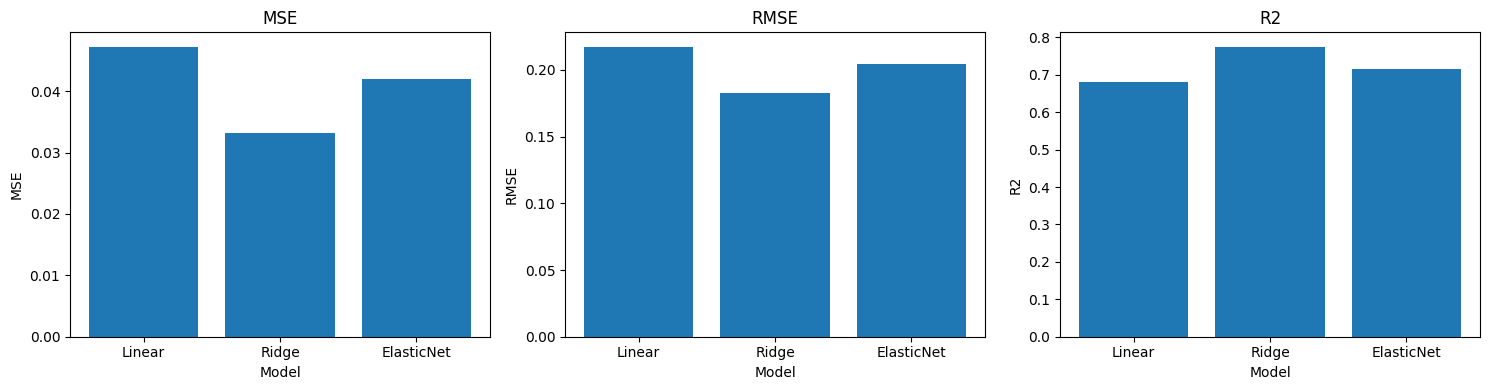

In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load models
# -----------------------------
paths = {
    "Linear": "/user/home/il22158/work/vEcoli/surrogate/baseline_linear_TU_model.pkl",
    "Ridge": "/user/home/il22158/work/vEcoli/surrogate/ridge_TU_model.pkl",
    "ElasticNet": "/user/home/il22158/work/vEcoli/surrogate/elasticnet_TU_model.pkl"
}

models = {name: joblib.load(path) for name, path in paths.items()}

# -----------------------------
# Evaluate
# -----------------------------
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, rmse, r2])

df_results = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])
print(df_results)

# -----------------------------
# BAR PLOT (NEW)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ["MSE", "RMSE", "R2"]

for i, metric in enumerate(metrics):
    axes[i].bar(df_results["Model"], df_results[metric])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("Model")

plt.tight_layout()
plt.show()

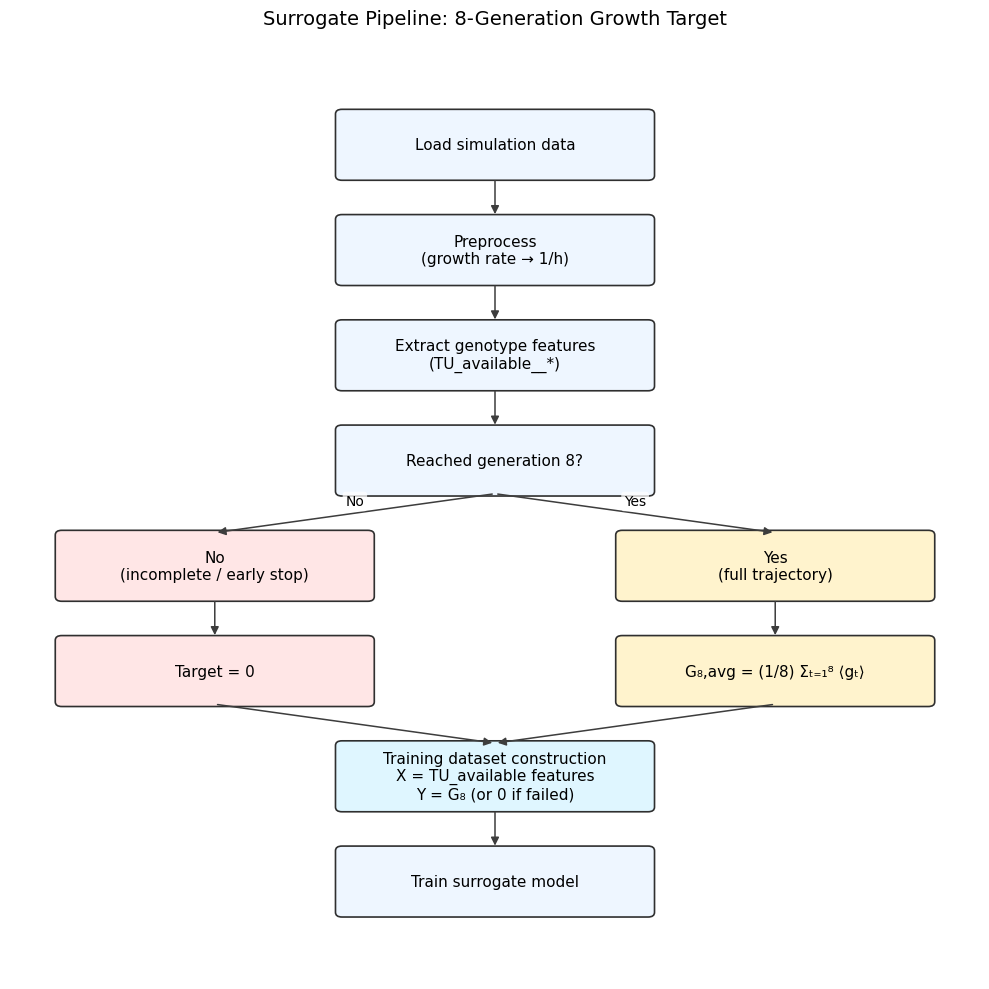

Saved: /user/home/il22158/work/vEcoli/surrogate/train_data/workflow_flowchart_8gen_avg_growth_TU_featured.png


In [ ]:
"""TU_level_training_dataset_growth_filtered.csv - New flowchart
"""
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TRAIN_DIR = "/user/home/il22158/work/vEcoli/surrogate/train_data"


# ---------------- box ----------------
def box(ax, x, y, t, w=2.9, h=0.85, c="#eef6ff", fs=11):
    p = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.06",
        facecolor=c,
        edgecolor="#2f2f2f",
        linewidth=1.2,
    )
    ax.add_patch(p)
    ax.text(x, y, t, ha="center", va="center", fontsize=fs, wrap=True)
    return w, h


# ---------------- improved geometry-aware arrow ----------------
def arrow(ax, a, b, aw=2.9, ah=0.85, bw=2.9, bh=0.85, label=None, fs=10):

    def edge_point(src, dst, w, h):
        dx = dst[0] - src[0]
        dy = dst[1] - src[1]

    # Horizontal connection
        x = src[0]
        y = src[1] + (h / 2) * (1 if dy > 0 else -1)

        return (x, y)

    start = edge_point(a, b, aw, ah)
    end = edge_point(b, a, bw, bh)

    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=12,
            linewidth=1.1,
            color="#3d3d3d"
        )
    )

    if label:
        ax.text(
            (start[0] + end[0]) / 2,
            (start[1] + end[1]) / 2 + 0.15,
            label,
            ha="center",
            va="center",
            fontsize=fs,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75)
        )


# ---------------- figure ----------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title("Surrogate Pipeline: 8-Generation Growth Target", fontsize=14, pad=14)

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-3.2, 8.8)
ax.axis("off")


# ---------------- uniform vertical spacing ----------------
start = 7.5
bottom = -0.6
n_levels = 7  # number of horizontal layers

step = (start - bottom) / (n_levels - 1)
ys = [start - i * step for i in range(n_levels)]


# ---------------- nodes ----------------
w, h = box(ax, 0, ys[0], "Load simulation data")

w, h = box(ax, 0, ys[1], "Preprocess\n(growth rate → 1/h)")

w, h = box(ax, 0, ys[2], "Extract genotype features\n(TU_available__*)")

w, h = box(ax, 0, ys[3], "Reached generation 8?")

w, h = box(ax, -2.6, ys[4], "No\n(incomplete / early stop)", c="#ffe6e6")
w2, h2 = box(ax, 2.6, ys[4], "Yes\n(full trajectory)", c="#fff3cd")

w3, h3 = box(ax, -2.6, ys[5], "Target = 0", c="#ffe6e6")

w4, h4 = box(ax, 2.6, ys[5],
    "G₈,avg = (1/8) Σₜ₌₁⁸ ⟨gₜ⟩", c="#fff3cd"
)

w5, h5 = box(
    ax,
    0,
    ys[6],
    "Training dataset construction\n"
    "X = TU_available features\n"
    "Y = G₈ (or 0 if failed)",
    c="#dff6ff"
)

w7, h7 = box(ax, 0, ys[6] - step, "Train surrogate model")


# ---------------- arrows ----------------
arrow(ax, (0, ys[0]), (0, ys[1]), w, h, w, h)
arrow(ax, (0, ys[1]), (0, ys[2]), w, h, w, h)
arrow(ax, (0, ys[2]), (0, ys[3]), w, h, w, h)

arrow(ax, (0, ys[3]), (-2.6, ys[4]), w, h, w2, h2, "No")
arrow(ax, (0, ys[3]), (2.6, ys[4]), w, h, w2, h2, "Yes")

arrow(ax, (-2.6, ys[4]), (-2.6, ys[5]), w2, h2, w3, h3)
arrow(ax, (2.6, ys[4]), (2.6, ys[5]), w2, h2, w4, h4)

arrow(ax, (-2.6, ys[5]), (0, ys[6]), w3, h3, w5, h5)
arrow(ax, (2.6, ys[5]), (0, ys[6]), w4, h4, w5, h5)

arrow(ax, (0, ys[6]), (0, ys[6] - step), w5, h5, w7, h7)


# ---------------- save ----------------
fig.tight_layout()

out_path = Path(TRAIN_DIR) / "workflow_flowchart_8gen_avg_growth_TU_featured.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.4)

plt.show()

print(f"Saved: {out_path}")